# Machine Learning - Second Hand Car Price Prediction
---

## Import data and libraries

In [1]:
# base modules
from pathlib import Path
import logging
from collections import OrderedDict

# for manipulating data
import numpy as np
import pandas as pd
import math
from typing import Callable
import copy
import re
from pandas.api.types import is_string_dtype, is_numeric_dtype


# for Machine Learning
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV,train_test_split

# for visualization
from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# for package auto reload
%load_ext autoreload
%autoreload 2

# for better rendering of plots in jupyter notebook
%matplotlib inline

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../feature"))
from feature_engineering import outliers_proc, feature_engineering
from transform_to_log import transform_price_to_log
from process_data import fix_missing, process_df, numericalize, reduce_mem_usage


In [3]:
df=pd.read_csv('../data/used_car_train_20200313.csv', sep=' ')
testA=pd.read_csv('../data/used_car_testA_20200313.csv', sep=' ')

---
## Data Processing & Feature Engineering

In [4]:
df_log=transform_price_to_log(df, save_path='../user_data/price_log_transform.csv')
df_log=outliers_proc(df_log, 'power',scale=3)
df_fe=feature_engineering(df_log)

Saved to ../user_data/price_log_transform.csv
Delete number is: 127
Now row count is: 149873
Description of data less than the lower bound is:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: power, dtype: float64
Description of data larger than the upper bound is:
count      127.000000
mean      3498.811024
std       4498.219286
min        650.000000
25%       1037.500000
50%       1503.000000
75%       2760.500000
max      19312.000000
Name: power, dtype: float64


In [5]:
df_fe=reduce_mem_usage(df_fe)
continuous_feature_names = [x for x in df_fe.columns if x not in ['price_log','brand','model','brand']]
df_pr,y,nas=process_df(df_fe,'price_log')
print(df_pr.shape)
df_pr.head()

Memory usage of dataframe is 39566604.00 MB
Memory usage after optimization is: 10790988.00 MB
Decreased by 72.7%
(149873, 41)


,SaleID,name,model,brand,bodyType,fuelType,gearbox,power,kilometer,notRepairedDamage,...,power_bin,model_na,bodyType_na,fuelType_na,gearbox_na,notRepairedDamage_na,used_time_na,km_per_year_na,power_age_na,power_bin_na
0,0,736,30.0,6,1.0,0.0,0.0,60,12.5,0.0,...,5.0,False,False,False,False,False,False,False,False,False
1,1,2262,40.0,1,2.0,0.0,0.0,0,15.0,0.0,...,11.0,False,False,False,False,True,False,False,False,True
2,2,14874,115.0,15,1.0,0.0,0.0,163,12.5,0.0,...,16.0,False,False,False,False,False,False,False,False,False
3,3,71865,109.0,10,0.0,0.0,1.0,193,15.0,0.0,...,19.0,False,False,False,False,False,False,False,False,False
4,4,111080,110.0,5,1.0,0.0,0.0,68,5.0,0.0,...,6.0,False,False,False,False,False,False,False,False,False


In [6]:
len(y)
y

array([7.52348131, 8.18896686, 8.73600738, ..., 8.92279162, 8.51719319,
       8.45553053], shape=(149873,))

In [7]:
df_pr.columns

Index(['SaleID', 'name', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox',
       'power', 'kilometer', 'notRepairedDamage', 'seller', 'offerType', 'v_0',
       'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10',
       'v_11', 'v_12', 'v_13', 'v_14', 'used_time', 'city', 'km_per_year',
       'power_age', 'power_bin', 'model_na', 'bodyType_na', 'fuelType_na',
       'gearbox_na', 'notRepairedDamage_na', 'used_time_na', 'km_per_year_na',
       'power_age_na', 'power_bin_na'],
      dtype='object')

---

## Base model

---
## Split Train & Validation set

In [8]:
N_valid = 30000
N_small = 30000
X_train, X_valid, y_train, y_valid = train_test_split(df_pr, y, test_size=N_valid, random_state=42)
_, X_small, _, y_small = train_test_split(X_train, y_train, test_size=N_small, random_state=42)
print("Large training set size : ",X_train.shape, y_train.shape)
print("Small training set size : ",X_small.shape, y_small.shape)
print("Validation set size : ",X_valid.shape, y_valid.shape)

Large training set size :  (119873, 41) (119873,)
Small training set size :  (30000, 41) (30000,)
Validation set size :  (30000, 41) (30000,)


In [9]:
X_train.columns

Index(['SaleID', 'name', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox',
       'power', 'kilometer', 'notRepairedDamage', 'seller', 'offerType', 'v_0',
       'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10',
       'v_11', 'v_12', 'v_13', 'v_14', 'used_time', 'city', 'km_per_year',
       'power_age', 'power_bin', 'model_na', 'bodyType_na', 'fuelType_na',
       'gearbox_na', 'notRepairedDamage_na', 'used_time_na', 'km_per_year_na',
       'power_age_na', 'power_bin_na'],
      dtype='object')

- define root mean squared error

In [10]:
def rmse(y_gold, y_pred): 
    return math.sqrt(((y_gold - y_pred)**2).mean())

- define print score(train/valid+oob)

In [11]:
def print_score(m, X_train, y_train, X_valid, y_valid, log_target=True):
    y_train_pred_log = m.predict(X_train)
    y_valid_pred_log = m.predict(X_valid)
    print('1. RMSE on train set (log_price): {:.4f}'.format(rmse(y_train, y_train_pred_log)))
    print('2. RMSE on valid set (log_price): {:.4f}'.format(rmse(y_valid, y_valid_pred_log)))
    print('3. MAE on train set (log_price): {:.4f}'.format(mean_absolute_error(y_train, y_train_pred_log)))
    print('4. MAE on valid set (log_price): {:.4f}'.format(mean_absolute_error(y_valid, y_valid_pred_log)))
    if log_target:
        y_train_real      = np.expm1(y_train)
        y_valid_real      = np.expm1(y_valid)
        y_train_pred_real = np.expm1(y_train_pred_log)
        y_valid_pred_real = np.expm1(y_valid_pred_log)
        print('5. R^2 on train set (original price): {:.4f}'.format(
            r2_score(y_train_real, y_train_pred_real)))
        print('6. R^2 on valid set (original price): {:.4f}'.format(
            r2_score(y_valid_real, y_valid_pred_real)))

    else:
        print('5. R^2 on train set: {:.4f}'.format(m.score(X_train, y_train)))
        print('6. R^2 on valid set: {:.4f}'.format(m.score(X_valid, y_valid)))
    if hasattr(m, 'oob_score_'):
        print('R^2 on oob set: {:.4f}'.format(m.oob_score_))

    return

---
## Training

- Small scale experiment

In [12]:
base_model = RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=42)
base_model.fit(X_small, y_small)
print_score(base_model, X_small, y_small, X_valid, y_valid)

1. RMSE on train set (log_price): 0.1178
2. RMSE on valid set (log_price): 0.2716
3. MAE on train set (log_price): 0.0663
4. MAE on valid set (log_price): 0.1624
5. R^2 on train set (original price): 0.9856
6. R^2 on valid set (original price): 0.9490


In [13]:
base_model = RandomForestRegressor(n_estimators = 10, n_jobs = -1, random_state = 42)

%time base_model.fit(X_train, y_train)
print_score(base_model, X_train, y_train, X_valid, y_valid)

CPU times: total: 45.8 s
Wall time: 5.67 s
1. RMSE on train set (log_price): 0.1097
2. RMSE on valid set (log_price): 0.2518
3. MAE on train set (log_price): 0.0586
4. MAE on valid set (log_price): 0.1431
5. R^2 on train set (original price): 0.9906
6. R^2 on valid set (original price): 0.9620


- Randomized splitting strategy

In [14]:
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 20, 
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, 
    max_samples = None,
)


cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)
print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.94959683 0.9499215  0.95545201 0.95328142 0.95318787]
r2 is 0.952 with a standard deviation of 0.002


---
## Hyperparmeter tuning

In [15]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': None,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': True,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

- Best model gird search

In [16]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 4],
    'max_features': ['sqrt', 0.5],
    'max_samples': [0.8, None], 
}
model = RandomForestRegressor(
    random_state = 42,
    bootstrap = True,
    n_jobs=-1
)

In [17]:
tuned_model = GridSearchCV(
    estimator = model, 
    param_grid = param_grid, 
    scoring = None, 
    n_jobs = -1, 
    refit = True, 
    cv = 5, 
    return_train_score = True,
    verbose = 2,
)

In [18]:
tuned_model.fit(X_small, y_small)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [20, 30, ...], 'max_features': ['sqrt', 0.5], 'max_samples': [0.8, None], 'min_samples_split': [2, 4], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,200


In [19]:
best_model = tuned_model.best_estimator_
best_model

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
print_score(best_model, X_small, y_small, X_valid, y_valid)

1. RMSE on train set (log_price): 0.1110
2. RMSE on valid set (log_price): 0.2521
3. MAE on train set (log_price): 0.0644
4. MAE on valid set (log_price): 0.1495
5. R^2 on train set (original price): 0.9872
6. R^2 on valid set (original price): 0.9545


In [21]:
%time best_model.fit(X_train, y_train)
print_score(best_model, X_train, y_train, X_valid, y_valid)

CPU times: total: 5min 20s
Wall time: 24.9 s
1. RMSE on train set (log_price): 0.1170
2. RMSE on valid set (log_price): 0.2340
3. MAE on train set (log_price): 0.0663
4. MAE on valid set (log_price): 0.1330
5. R^2 on train set (original price): 0.9909
6. R^2 on valid set (original price): 0.9666


In [22]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(best_model, X_small, y_small, cv = cv, n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95051613 0.95132961 0.95709638 0.95467211 0.95473754]
r2 is 0.954 with a standard deviation of 0.002


In [23]:
import joblib

joblib.dump(best_model, '../user_data/best_model.joblib')

['../user_data/best_model.joblib']

---
## XGBoost

In [24]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor, Pool, cv, CatBoostClassifier
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, train_test_split
from sklearn import metrics
from xgboost import XGBRegressor, plot_tree
import seaborn as sns

In [25]:
def reg_perf(regressor, X_training, X_validation, y_true_training, y_true_validation, plot=True):
    """
    Evaluate the performance of a regression model.

    Parameters
    ----------
    regressor: sklearn.base.BaseEstimator. A trained scikit-learn regressor.
    X_training: pd.DataFrame. Table containing features used for training.
    X_validation: pd.DataFrame. Table containing features used for validation.
    y_true_training: array-like. List of true target variable values for training.
    y_true_validation: array-like. List of true target variable values for validation.
    plot: boolean. Whether to show a scatter plot of truth versus predictions.
    """
    y_pred_training = regressor.predict(X_training)
    y_pred_validation = regressor.predict(X_validation)
    rmse_training = metrics.root_mean_squared_error(y_true_training, y_pred_training)
    rmse_validation = metrics.root_mean_squared_error(y_true_validation, y_pred_validation)
    r2_training = metrics.r2_score(y_true_training, y_pred_training)
    r2_validation = metrics.r2_score(y_true_validation, y_pred_validation)
    print("RMSE on training set : {:.3f}".format(rmse_training))
    print("RMSE on validation set : {:.3f}".format(rmse_validation))
    print("R^2 on training set : {:.3f}".format(r2_training))
    print("R^2 on validation set : {:.3f}".format(r2_validation))

    if plot:
        sns.regplot(x=y_true_validation, y=y_pred_validation,  scatter_kws={'s': 1, 'alpha':0.7})
        plt.xlabel("true target variable")
        plt.ylabel("predicted target variable")
        plt.title("Regressor prediction vs truth on validation set")
        plt.show()

[7.52348131 8.18896686 8.73600738 ... 8.92279162 8.51719319 8.45553053]
count    149873.000000
mean          8.035481
std           1.218081
min           2.484907
25%           7.170888
50%           8.086718
75%           8.949105
max          11.512925
dtype: float64


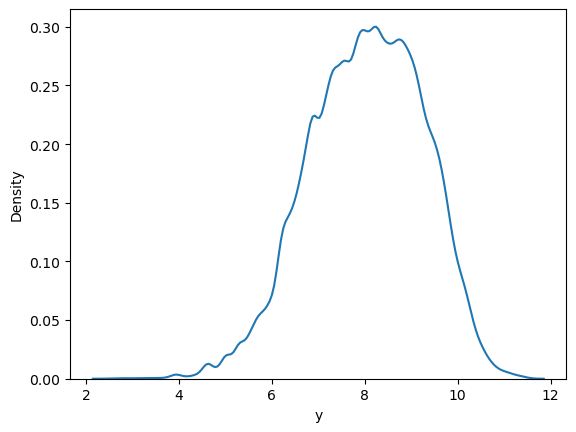

In [26]:
print(y)
print(pd.Series(y).describe())
sns.kdeplot(y)
plt.xlabel("y")
plt.show()

In [27]:
xgb = XGBRegressor(
colsample_bytree=0.8,
 gamma=0.0,
 learning_rate=0.05,
 max_depth= 8,
 min_child_weight=3,
 n_estimators=400,
 reg_lambda=1.0,
 subsample= 1.0         
)

In [28]:
%time xgb.fit(X_small, y_small)

CPU times: total: 11.3 s
Wall time: 3.38 s


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


RMSE on training set : 0.111
RMSE on validation set : 0.240
R^2 on training set : 0.992
R^2 on validation set : 0.961


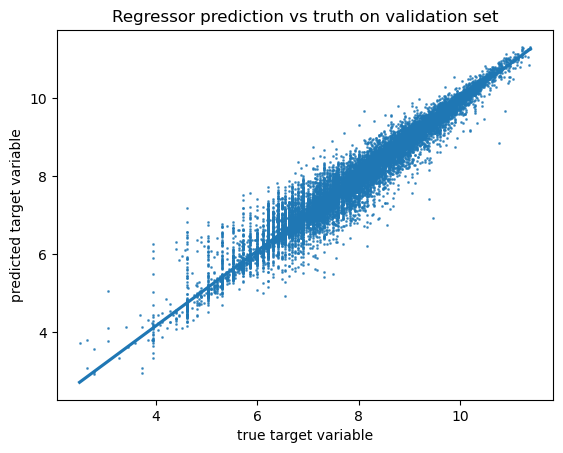

In [29]:
reg_perf(xgb, X_small, X_valid, y_small, y_valid)

CPU times: total: 18.9 s
Wall time: 1.72 s
RMSE on training set : 0.164
RMSE on validation set : 0.225
R^2 on training set : 0.982
R^2 on validation set : 0.966


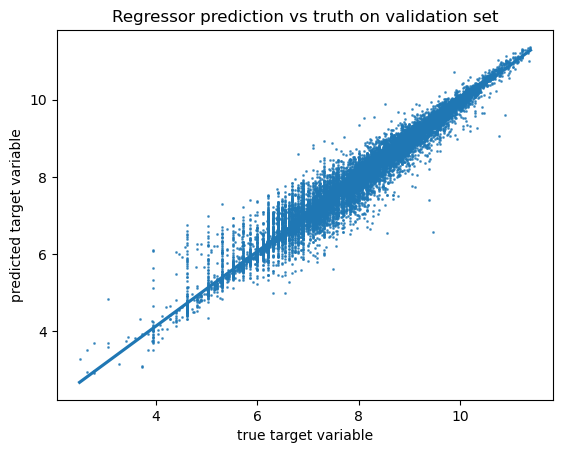

In [30]:
%time xgb.fit(X_train, y_train)
reg_perf(xgb, X_train, X_valid, y_train, y_valid)

---
## Using Optuna

In [31]:
import optuna

In [32]:
def objective(trial, X_training, y_training, X_validation, y_validation):
    """
    This function estimates a trial quality.
    It contains the 4 steps : hp sampling, model definition, training and evaluation.
    
    Parameters:
    ----------
    trial (optuna.trial.Trial): the trial at stake
    X_training: pd.DataFrame. Table containing features used for training.
    X_validation: pd.DataFrame. Table containing features used for validation.
    y_training: array-like. List of true target variable values for training.
    y_validation: array-like. List of true target variable values for validation.

    Returns:
    -------
    float: performance metric value (R^2)
    """
    
    learning_rate_guess = trial.suggest_float("learning_rate", 1e-3, 1, log=True)
    max_depth_guess = trial.suggest_int("max_depth", 2, 30, log=False)
    reg_lambda_guess = trial.suggest_int("reg_lambda", 1,100, log=False)
    colsample_bytree_guess = trial.suggest_float("colsample_bytree", 0.3, 1.0, log=False)
    min_child_weight_guess = trial.suggest_int("min_child_weight", 1, 10, log=False)
    subsample_guess = trial.suggest_float("subsample", 0.5, 1.0, log=False)
    gamma_guess = trial.suggest_float("gamma", 0.0, 5.0, log=False)
    

    
    xgb = XGBRegressor(
        n_estimators=1000,                              
        random_state=42,
        learning_rate=learning_rate_guess,       
        max_depth=max_depth_guess, 
        reg_lambda=reg_lambda_guess,
        verbosity=0,
        colsample_bytree=colsample_bytree_guess,
        min_child_weight=min_child_weight_guess,   
        subsample=subsample_guess  ,
        gamma=gamma_guess        
    )
    
    xgb.fit(X_training, y_training)
    
    y_pred_validation = xgb.predict(X_validation)
    r2_validation = metrics.r2_score(y_validation, y_pred_validation)
    return r2_validation

In [33]:
study = optuna.create_study(study_name="xgb_opt", 
                            load_if_exists=True, 
                            storage = "sqlite:///opt.db",
                            direction="maximize")

study.optimize(lambda trial: objective(trial, X_small, y_small, X_valid, y_valid), n_trials=50, show_progress_bar=True)

[I 2025-11-28 16:25:56,960] Using an existing study with name 'xgb_opt' instead of creating a new one.


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-28 16:25:58,064] Trial 50 finished with value: 0.9563364177327351 and parameters: {'learning_rate': 0.01893099800950512, 'max_depth': 21, 'reg_lambda': 67, 'colsample_bytree': 0.500231776949937, 'min_child_weight': 5, 'subsample': 0.6241754425686262, 'gamma': 1.1041952282232972}. Best is trial 36 with value: 0.9607643978238638.
[I 2025-11-28 16:25:59,780] Trial 51 finished with value: 0.9608645781030004 and parameters: {'learning_rate': 0.030849896793733088, 'max_depth': 23, 'reg_lambda': 86, 'colsample_bytree': 0.3890741769573908, 'min_child_weight': 6, 'subsample': 0.6969000448424943, 'gamma': 0.2071400182980532}. Best is trial 51 with value: 0.9608645781030004.
[I 2025-11-28 16:26:01,512] Trial 52 finished with value: 0.9610945149795714 and parameters: {'learning_rate': 0.03727178569114448, 'max_depth': 27, 'reg_lambda': 96, 'colsample_bytree': 0.3861498554001375, 'min_child_weight': 6, 'subsample': 0.6937221574343347, 'gamma': 0.18532076245258736}. Best is trial 52 with 

In [34]:
study.best_params

{'learning_rate': 0.018417194507054865,
 'max_depth': 30,
 'reg_lambda': 45,
 'colsample_bytree': 0.4061076872827357,
 'min_child_weight': 8,
 'subsample': 0.6544138727094074,
 'gamma': 0.09039517304105003}

[0]	validation_0-rmse:1.19971
[1]	validation_0-rmse:1.18009
[2]	validation_0-rmse:1.16090
[3]	validation_0-rmse:1.14214
[4]	validation_0-rmse:1.12356
[5]	validation_0-rmse:1.10527
[6]	validation_0-rmse:1.08963
[7]	validation_0-rmse:1.07221
[8]	validation_0-rmse:1.05482
[9]	validation_0-rmse:1.03790
[10]	validation_0-rmse:1.02225
[11]	validation_0-rmse:1.00583
[12]	validation_0-rmse:0.98977
[13]	validation_0-rmse:0.97403
[14]	validation_0-rmse:0.95858
[15]	validation_0-rmse:0.94347
[16]	validation_0-rmse:0.92873
[17]	validation_0-rmse:0.91438
[18]	validation_0-rmse:0.90028
[19]	validation_0-rmse:0.88629
[20]	validation_0-rmse:0.87377
[21]	validation_0-rmse:0.86024
[22]	validation_0-rmse:0.84696
[23]	validation_0-rmse:0.83401
[24]	validation_0-rmse:0.82121
[25]	validation_0-rmse:0.80877
[26]	validation_0-rmse:0.79670
[27]	validation_0-rmse:0.78807
[28]	validation_0-rmse:0.77725
[29]	validation_0-rmse:0.76635
[30]	validation_0-rmse:0.75486
[31]	validation_0-rmse:0.74475
[32]	validation_0-

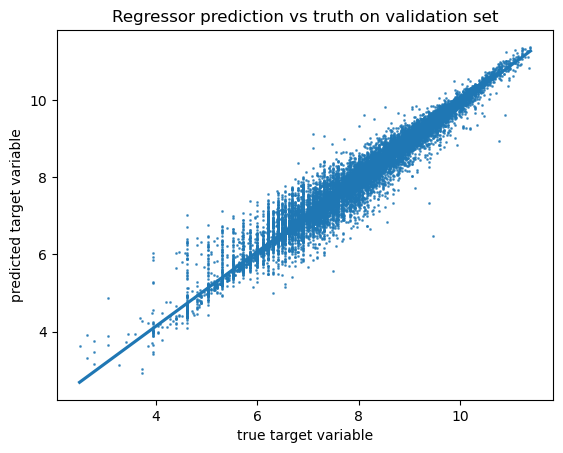

In [35]:
xgb_best = XGBRegressor(
        n_estimators=1000,                              
        random_state=42,
        learning_rate=0.018417194507054865,       
        max_depth=30, 
        reg_lambda=45,
        verbosity=0,
        colsample_bytree=0.4061076872827357,
        min_child_weight=8,   
        subsample=0.6544138727094074  ,
        gamma=0.09039517304105003          
)
%time xgb_best.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])
reg_perf(xgb_best, X_train, X_valid, y_train, y_valid, plot=True)

In [36]:
joblib.dump(xgb_best, '../user_data/XGBoost_Model.joblib')

['../user_data/XGBoost_Model.joblib']

---
## Top 10 Important Features

Top 10 important features:


v_3                  0.236691
bodyType_na          0.189477
v_12                 0.171353
v_0                  0.111262
v_8                  0.048427
notRepairedDamage    0.035901
v_10                 0.028941
used_time            0.028887
power                0.020447
kilometer            0.017595
dtype: float32

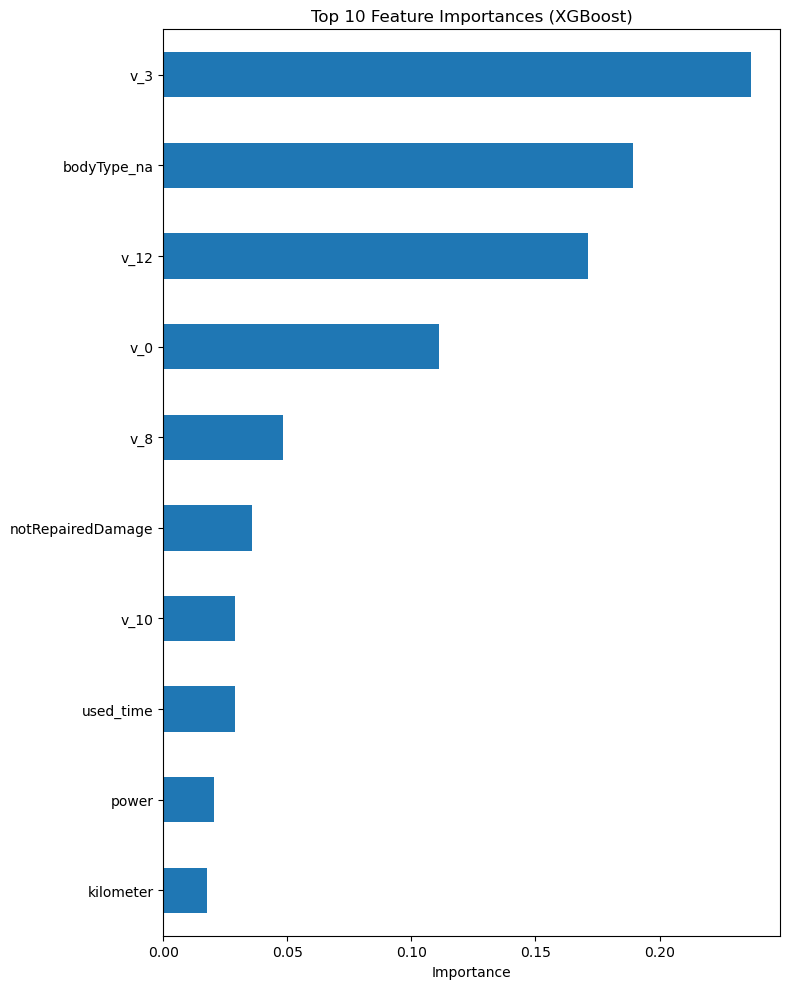

In [37]:
imp = pd.Series(xgb_best.feature_importances_, index=X_train.columns)
imp_sorted = imp.sort_values(ascending=False)
print("Top 10 important features:")
display(imp_sorted.head(10))
plt.figure(figsize=(8, 10))                  
imp_sorted.head(10).iloc[::-1].plot(kind='barh')  
plt.title(f"Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Top 10 important features:


v_3          0.430609
v_0          0.199325
v_12         0.195777
v_8          0.058276
v_10         0.029161
used_time    0.018469
v_11         0.010707
v_6          0.008424
v_1          0.005652
v_14         0.003856
dtype: float64

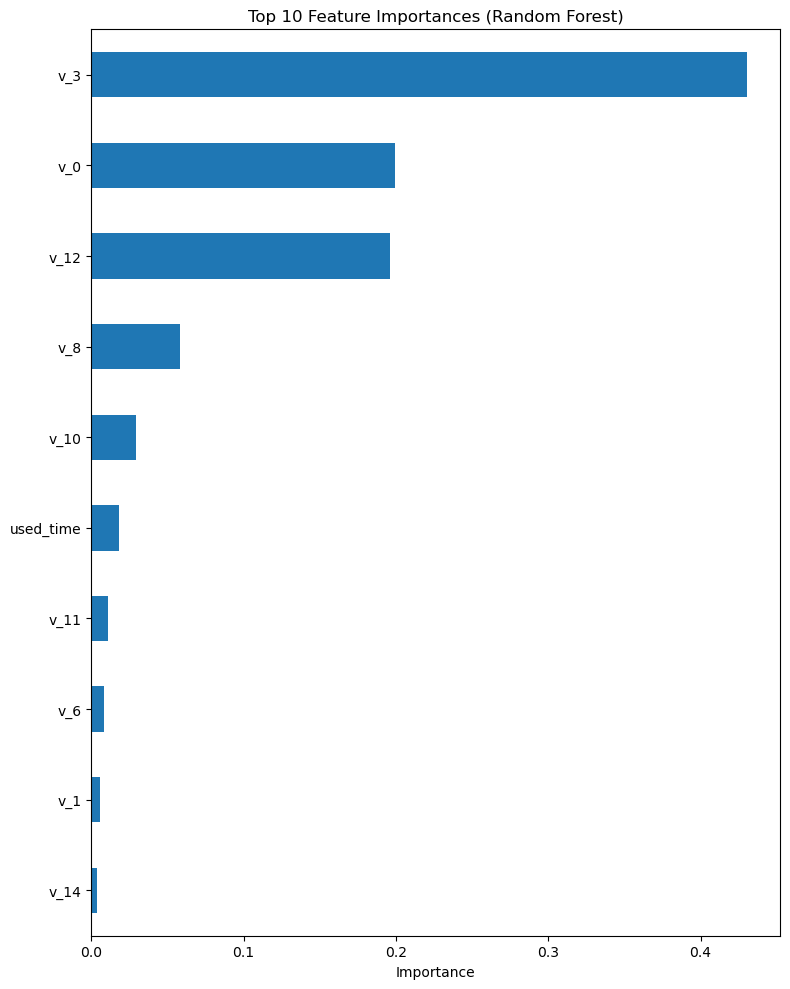

In [44]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
imp_sorted = imp.sort_values(ascending=False)
print("Top 10 important features:")
display(imp_sorted.head(10))
plt.figure(figsize=(8, 10))                  
imp_sorted.head(10).iloc[::-1].plot(kind='barh')  
plt.title(f"Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()